In [1]:
import sqlite3 
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

In [2]:
conn = sqlite3.connect("crime_data.db")

In [3]:
q = """
SELECT 
    SUM(CASE WHEN crime_id IS NULL THEN 1 ELSE 0 END) AS crime_id_nulls,
    SUM(CASE WHEN month IS NULL THEN 1 ELSE 0 END) AS month_nulls,
    SUM(CASE WHEN reported_by IS NULL THEN 1 ELSE 0 END) AS reported_by_nulls,
    SUM(CASE WHEN falls_within IS NULL THEN 1 ELSE 0 END) AS falls_within_nulls,
    SUM(CASE WHEN longitude IS NULL THEN 1 ELSE 0 END) AS longitude_nulls,
    SUM(CASE WHEN latitude IS NULL THEN 1 ELSE 0 END) AS latitude_nulls,
    SUM(CASE WHEN location IS NULL THEN 1 ELSE 0 END) AS location_nulls,
    SUM(CASE WHEN lsoa_code IS NULL THEN 1 ELSE 0 END) AS lsoa_code_nulls,
    SUM(CASE WHEN lsoa_name IS NULL THEN 1 ELSE 0 END) AS lsoa_name_nulls,
    SUM(CASE WHEN crime_type IS NULL THEN 1 ELSE 0 END) AS crime_type_nulls,
    SUM(CASE WHEN last_outcome_category IS NULL THEN 1 ELSE 0 END) AS outcome_nulls
FROM crimes;
"""

pd.read_sql_query(q, conn)

# approx 4% of lsoas missing

,crime_id_nulls,month_nulls,reported_by_nulls,falls_within_nulls,longitude_nulls,latitude_nulls,location_nulls,lsoa_code_nulls,lsoa_name_nulls,crime_type_nulls,outcome_nulls
0,2805319,0,0,0,262200,262200,0,265120,265120,0,2805319


In [4]:
pd.read_sql_query("""SELECT count(*) as missing
                  from crimes 
                  where latitude is NULL and longitude is NULL and lsoa_code is NULL""", conn)


,missing
0,262200


In [5]:
total = pd.read_sql("""select count(*) AS total
                    from crimes""", conn)["total"][0]

lsoa_missing = pd.read_sql("""select count(*) AS missing
                           from crimes
                           where lsoa_code IS NULL""", conn)["missing"][0]

miss_rate = lsoa_missing/total

print("total rows num:", f"{total:,}")
print("missing lsoas:", f"{lsoa_missing:,}", f"({miss_rate * 100:.1f}%)")

total rows num: 17,425,458
missing lsoas: 265,120 (1.5%)


In [6]:
# missing LSOA code per police force 

force_miss = pd.read_sql("""
select reported_by, COUNT(*) AS total,
SUM(CASE WHEN lsoa_code IS NULL THEN 1 ELSE 0 END) AS missing
from crimes
group by reported_by              
""", conn)

force_miss["missing_rate"] = round(force_miss["missing"] / force_miss["total"] * 100, 2)
force_miss = force_miss.sort_values("missing_rate", ascending = False)

print(force_miss.to_string(index = False))

                   reported_by   total  missing  missing_rate
         City of London Police   27984     2370          8.47
Avon and Somerset Constabulary  565360    42601          7.54
            Dyfed-Powys Police  118602     7539          6.36
       Devon & Cornwall Police  401071    19374          4.83
        South Yorkshire Police  530231    24225          4.57
           Bedfordshire Police  186316     7508          4.03
  Gloucestershire Constabulary  175954     7053          4.01
      British Transport Police   78789     2888          3.67
                 Sussex Police  481201    17033          3.54
   Cambridgeshire Constabulary  251189     8132          3.24
       Lancashire Constabulary  544575    17097          3.14
         Leicestershire Police  322230     9395          2.92
            South Wales Police  398118     9720          2.44
          Thames Valley Police  594801    13264          2.23
          Norfolk Constabulary  205862     4520          2.20
    Hert

                  crime_type   total  missing  missing_rate
                 Other crime  359426    10493      2.919377
                       Drugs  537474    12020      2.236387
       Possession of weapons  161574     3447      2.133388
                 Other theft 1253612    25683      2.048720
                Public order 1251193    23813      1.903224
               Bicycle theft  166510     3043      1.827518
                     Robbery  224430     4099      1.826405
Violence and sexual offences 6037876   106096      1.757174
   Criminal damage and arson 1302508    21122      1.621641
       Theft from the person  357409     5733      1.604045
                    Burglary  689817    10323      1.496484
                 Shoplifting 1374065    20420      1.486101
               Vehicle crime  983034    14174      1.441863
       Anti-social behaviour 2726530     4654      0.170693


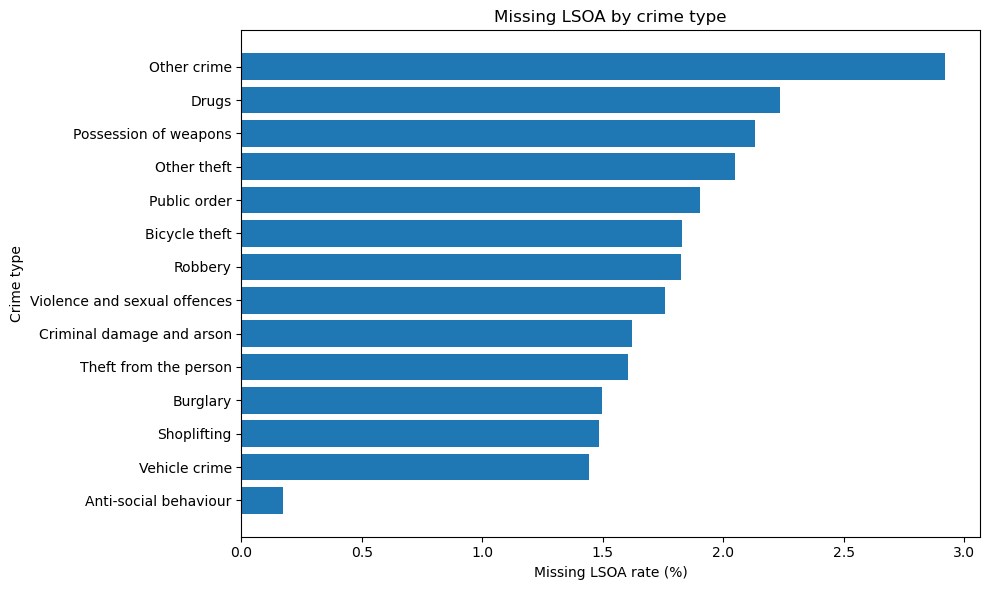

In [7]:
# missing lsoas per crime type

crime_miss = pd.read_sql("""select crime_type, count(*) AS total,
                         SUM(CASE WHEN lsoa_code IS NULL THEN 1 ELSE 0 END) AS missing
                         from crimes
                         group by crime_type""", conn)

crime_miss["missing_rate"] = crime_miss["missing"] / crime_miss["total"] * 100
crime_miss = crime_miss.sort_values("missing_rate", ascending = False)

print(crime_miss.to_string(index = False))

plt.figure(figsize=(10,6))
plt.barh(crime_miss["crime_type"], crime_miss["missing_rate"])
plt.gca().invert_yaxis()
plt.xlabel("Missing LSOA rate (%)")
plt.ylabel("Crime type")
plt.title("Missing LSOA by crime type")
plt.tight_layout()
plt.show()

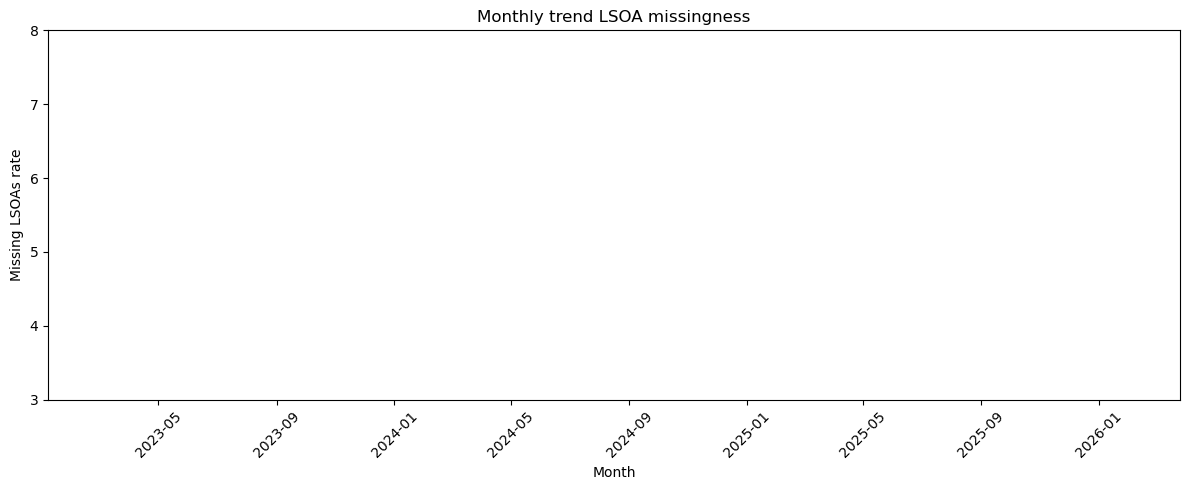

In [8]:

month_miss = pd.read_sql("""select month, count(*) AS total,
                         SUM(CASE WHEN lsoa_code IS NULL OR lsoa_code = '' THEN 1 ELSE 0 END) AS missing
                         from crimes
                         group by month""", conn)

month_miss["missing_rate"]= month_miss["missing"] / month_miss["total"] * 100
month_miss["month"] = pd.to_datetime(month_miss["month"], format="%Y-%m")
month_miss = month_miss.sort_values("month", ascending=True)

plt.figure(figsize=(12,5))
plt.plot(month_miss["month"], month_miss["missing_rate"], marker = "o", color = 'indigo')
plt.ylim(3, 8)
plt.xlabel("Month")
plt.ylabel("Missing LSOAs rate")
plt.title("Monthly trend LSOA missingness")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [9]:
# missing crime ID by police force. As we can see, British Transport Police does not generate crime_IDs

ID_force_miss = pd.read_sql("""select reported_by, count(*) AS total,
                            sum(CASE WHEN crime_ID is NULL THEN 1 ELSE 0 END) AS missing
                            from crimes
                            group by reported_by""", conn)

ID_force_miss["missing_rate"] = round(ID_force_miss["missing"] / ID_force_miss["total"] * 100, 2)
ID_force_miss = ID_force_miss.sort_values("missing_rate", ascending = False)

print(ID_force_miss.to_string(index = False))

                   reported_by   total  missing  missing_rate
      British Transport Police   78789    78789        100.00
       Lancashire Constabulary  544575   153334         28.16
        North Yorkshire Police  185446    45206         24.38
                 Dorset Police  178294    42572         23.88
    Hertfordshire Constabulary  315814    69315         21.95
           Lincolnshire Police  205228    42540         20.73
              Wiltshire Police  154132    31894         20.69
            North Wales Police  196448    40231         20.48
   Metropolitan Police Service 3390941   693470         20.45
            Northumbria Police  515425   104245         20.23
        Nottinghamshire Police  377733    74202         19.64
  Gloucestershire Constabulary  175954    33405         18.99
              Cleveland Police  275167    51024         18.54
       Northamptonshire Police  220558    40772         18.49
           Warwickshire Police  148958    27302         18.33
        

In [10]:
# mising crime_id by crime type. As we can see, crime_ID is not generated for ASB

ID_by_crime_miss = pd.read_sql("""select crime_type, count(*) AS total,
                               sum(CASE WHEN crime_ID is NULL THEN 1 ELSE 0 END) AS missing
                               from crimes
                               group by crime_type""", conn)

ID_by_crime_miss["missing_rate"] = ID_by_crime_miss["missing"] / ID_by_crime_miss["total"] * 100
ID_by_crime_miss = ID_by_crime_miss.sort_values("missing_rate", ascending = False)

print(ID_by_crime_miss.to_string(index = False))

                  crime_type   total  missing  missing_rate
       Anti-social behaviour 2726530  2726530    100.000000
               Bicycle theft  166510     5247      3.151162
       Theft from the person  357409     9222      2.580237
                Public order 1251193    15493      1.238258
                     Robbery  224430     2779      1.238248
                 Other theft 1253612    11369      0.906899
       Possession of weapons  161574     1315      0.813869
   Criminal damage and arson 1302508     8599      0.660188
                       Drugs  537474     2972      0.552957
Violence and sexual offences 6037876    16635      0.275511
                 Other crime  359426      903      0.251234
               Vehicle crime  983034     2199      0.223695
                 Shoplifting 1374065     1660      0.120809
                    Burglary  689817      396      0.057407


In [11]:
q = """select count(DISTINCT reported_by) 
from crimes;"""
pd.read_sql_query(q, conn) 

,count(DISTINCT reported_by)
0,43


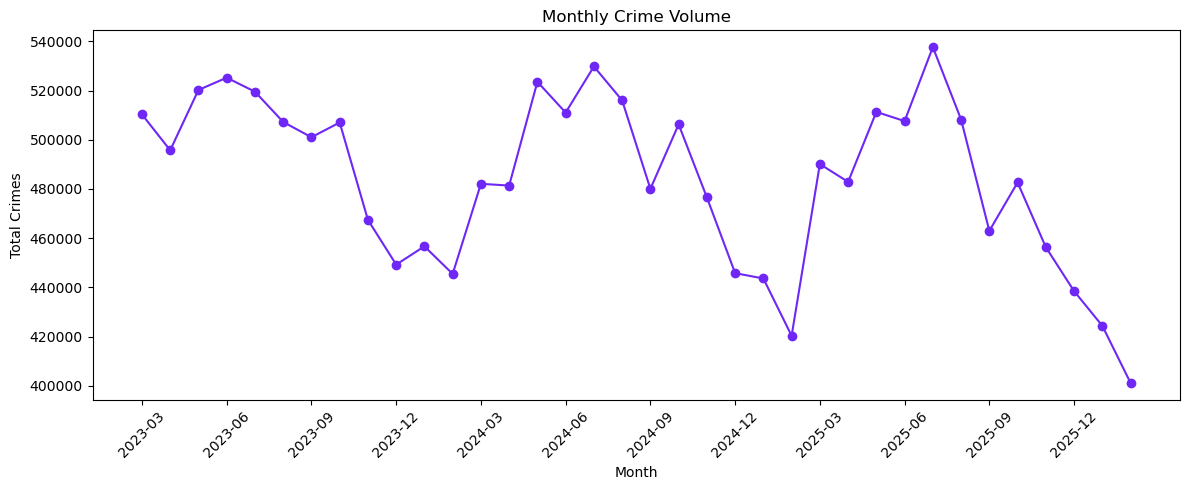

In [12]:
q = """select month, COUNT(*) as total_crimes
from crimes
group by month
order by month;"""

monthly = pd.read_sql_query(q, conn)
monthly["month"] = pd.to_datetime(monthly["month"], format= "%Y-%m")

monthly = (monthly.groupby(monthly["month"].dt.to_period("M"))["total_crimes"].sum().reset_index())
monthly["month"] = monthly["month"].astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly["month"], monthly["total_crimes"], marker="o", color = '#6F27F5')

plt.xticks(monthly["month"][::3], rotation=45)
plt.title("Monthly Crime Volume")
plt.xlabel("Month")
plt.ylabel("Total Crimes")
plt.tight_layout()
plt.show()

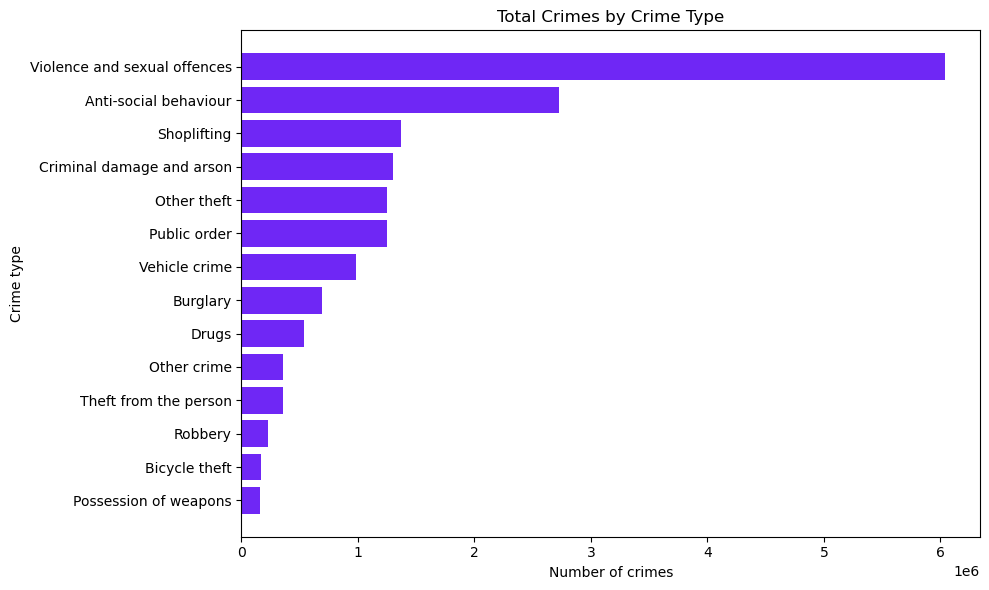

In [13]:
c = pd.read_sql("""select crime_type, count(*) AS total_crimes
                from crimes
                group by crime_type
                order by total_crimes DESC""", conn)

plt.figure(figsize=(10, 6))
plt.barh(c["crime_type"], c["total_crimes"], color = '#6F27F5')
plt.gca().invert_yaxis()
plt.title("Total Crimes by Crime Type")
plt.xlabel("Number of crimes")
plt.ylabel("Crime type")
plt.tight_layout()
plt.show()

C:\Users\20243755\AppData\Local\Temp\ipykernel_16640\2694954149.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filt["month"] = pd.to_datetime(filt["month"])


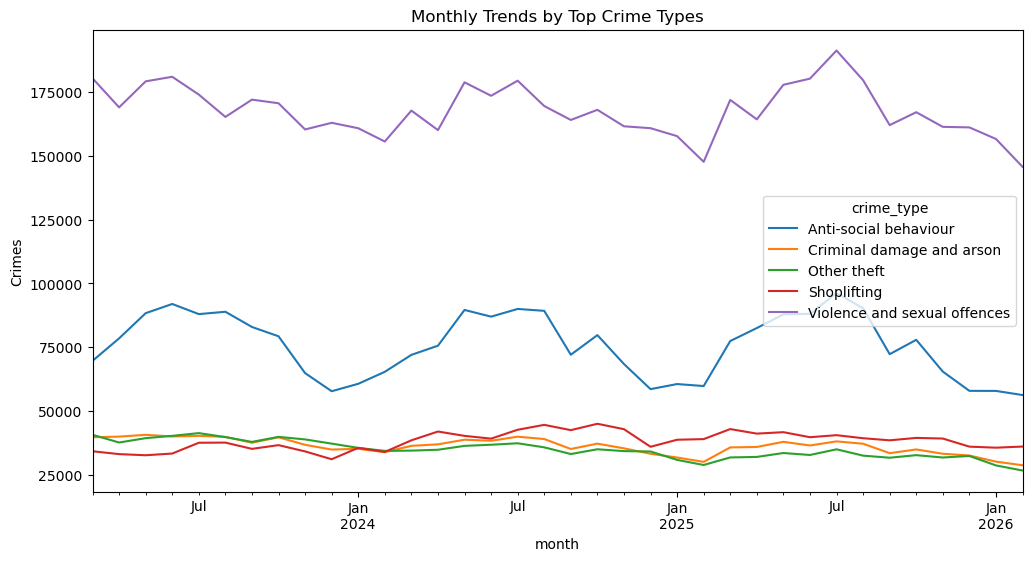

In [14]:
cm= pd.read_sql("""select month, crime_type, COUNT(*) as total
                from crimes
                group by month, crime_type""", conn)

top_types = c.head(5)["crime_type"].tolist()

filt = cm[cm["crime_type"].isin(top_types)]
filt["month"] = pd.to_datetime(filt["month"])

pivot = filt.pivot(index = "month", columns = "crime_type", values = "total").fillna(0)

pivot.plot(figsize=(12,6))
plt.title("Monthly Trends by Top Crime Types")
plt.ylabel("Crimes")
plt.show()

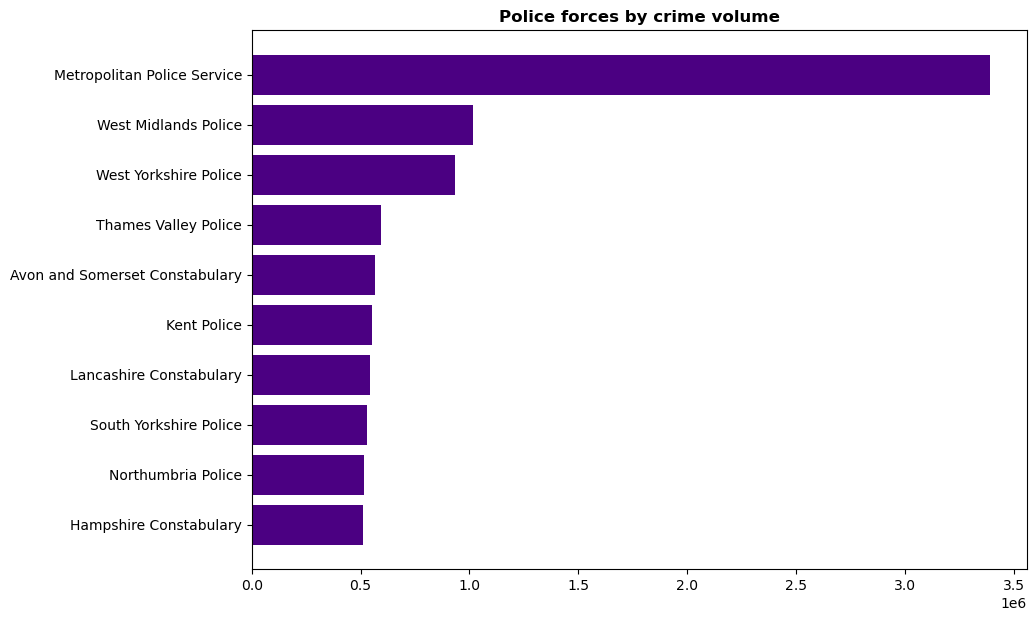

In [15]:
f = pd.read_sql("""select reported_by, count(*) as total
                FROM crimes
                group by reported_by
                order by total DESC""", conn)

top_force = f.head(10)

plt.figure(figsize=(10,7))
plt.barh(top_force["reported_by"], top_force["total"], color = 'indigo')
plt.gca().invert_yaxis()
plt.title("Police forces by crime volume", weight = 'bold')
plt.show()

# MPS handles 3-4 times larger volume that 2nd largest police force

C:\Users\20243755\AppData\Local\Temp\ipykernel_16640\4218611919.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fil["month"] = pd.to_datetime(fil["month"])


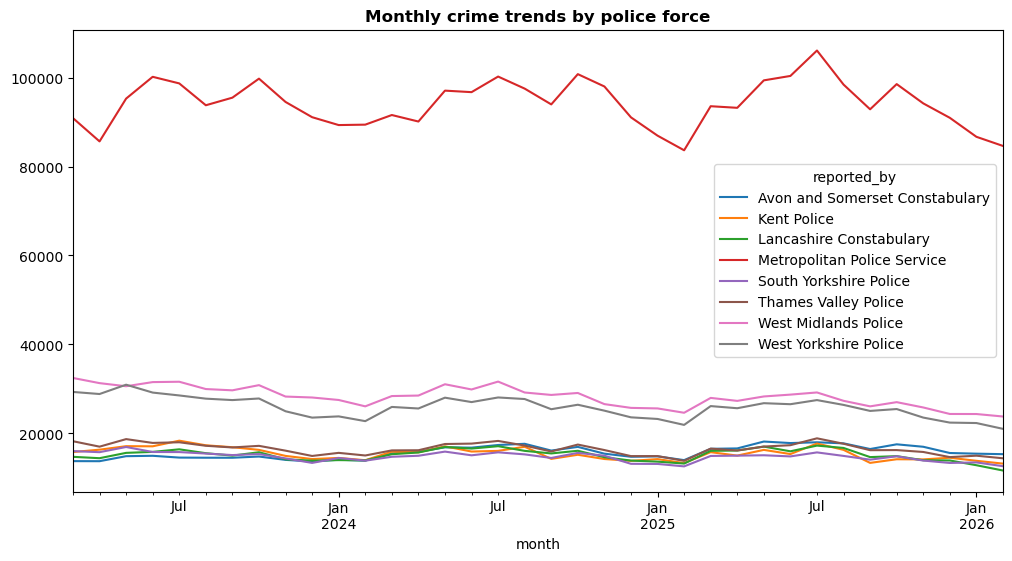

In [16]:
fm = pd.read_sql("""select month, reported_by, count(*) as total
                 from crimes
                 group by month, reported_by""", conn)

top_forces = f.head(8)["reported_by"].tolist()
fil = fm[fm["reported_by"].isin(top_forces)]
fil["month"] = pd.to_datetime(fil["month"])

pivot = fil.pivot(index = "month", columns = "reported_by", values ="total").fillna(0)
pivot.plot(figsize=(12,6))
plt.title("Monthly crime trends by police force", weight = 'bold')
plt.show()

In [ ]:
conn.close()